Diabetes Dataset Decision Tree

In [27]:
print("Hello world")

Hello world


In [28]:
import pandas as pd

In [29]:
# Age is in a differen scale than estimated salary. Thus we need to convert them into a standard scale.

In [30]:
df = pd.read_csv("/home/msis/ahegde/aml-lab/projects/data/diabetes.csv")

In [31]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [32]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [33]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [34]:
df.duplicated().sum()

np.int64(0)

In [126]:
x = df.iloc[:,1:8].values
x

array([[148.   ,  72.   ,  35.   , ...,  33.6  ,   0.627,  50.   ],
       [ 85.   ,  66.   ,  29.   , ...,  26.6  ,   0.351,  31.   ],
       [183.   ,  64.   ,   0.   , ...,  23.3  ,   0.672,  32.   ],
       ...,
       [121.   ,  72.   ,  23.   , ...,  26.2  ,   0.245,  30.   ],
       [126.   ,  60.   ,   0.   , ...,  30.1  ,   0.349,  47.   ],
       [ 93.   ,  70.   ,  31.   , ...,  30.4  ,   0.315,  23.   ]],
      shape=(768, 7))

In [127]:
y = df.iloc[:, -1].values
y

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1,

In [128]:
import numpy as np

In [140]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [141]:
from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()
x_train = sc_x.fit_transform(x_train)
x_test = sc_x.transform(x_test)

In [142]:
from sklearn import tree
#clf = tree.DecisionTreeClassifier(criterion='entropy', random_state=0)
clf = tree.DecisionTreeClassifier(criterion='entropy')

In [143]:
clf.fit(x_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [144]:
y_pred = clf.predict(x_test)

In [145]:
from sklearn.metrics import confusion_matrix

In [146]:
confusion_matrix(y_test, y_pred)

array([[93, 19],
       [27, 15]])

In [147]:
from sklearn.metrics import accuracy_score

In [148]:
accuracy = accuracy_score(y_test, y_pred)*100

In [149]:
accuracy

70.12987012987013

[Text(0.3990953947368421, 0.96875, 'x[0] <= 0.024\nentropy = 0.949\nsamples = 614\nvalue = [388.0, 226.0]'),
 Text(0.14819078947368422, 0.90625, 'x[4] <= -0.721\nentropy = 0.678\nsamples = 341\nvalue = [280, 61]'),
 Text(0.27364309210526316, 0.9375, 'True  '),
 Text(0.04342105263157895, 0.84375, 'x[5] <= 0.561\nentropy = 0.081\nsamples = 99\nvalue = [98, 1]'),
 Text(0.03289473684210526, 0.78125, 'entropy = 0.0\nsamples = 84\nvalue = [84, 0]'),
 Text(0.05394736842105263, 0.78125, 'x[5] <= 0.65\nentropy = 0.353\nsamples = 15\nvalue = [14, 1]'),
 Text(0.04342105263157895, 0.71875, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.06447368421052632, 0.71875, 'entropy = 0.0\nsamples = 14\nvalue = [14, 0]'),
 Text(0.25296052631578947, 0.84375, 'x[6] <= -0.255\nentropy = 0.808\nsamples = 242\nvalue = [182, 60]'),
 Text(0.13355263157894737, 0.78125, 'x[4] <= 1.676\nentropy = 0.592\nsamples = 140\nvalue = [120, 20]'),
 Text(0.08552631578947369, 0.71875, 'x[0] <= -0.918\nentropy = 0.544\nsa

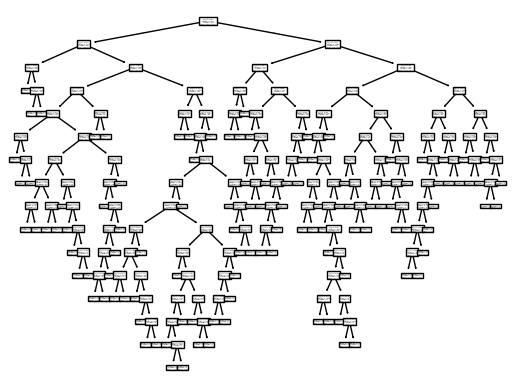

In [150]:
from sklearn import tree
tree.plot_tree(clf)